# From Pixels to Predictions — short version

- **Task** — `0 = cat`, `1 = dog`
- **Data** — Oxford-IIIT Pet (downloads once, ~800 MB)
- **Model** — ResNet-18 pretrained on ImageNet, last block fine-tuned
- **Runtime** — about a minute of training

In [1]:
import time, random
from pathlib import Path

import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights

SEED, DATA = 0, Path("data")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

pets = OxfordIIITPet(DATA, split="trainval", download=True)     # 37 breeds
OxfordIIITPet(DATA, split="test", download=True)

CAT_BREEDS = {"Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
              "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx"}
IS_CAT  = [breed in CAT_BREEDS for breed in pets.classes]       # 12 of the 37
CLASSES = ["cat", "dog"]
to_binary = lambda breed: 0 if IS_CAT[breed] else 1             # 37 breeds -> one bit

print(f"torch {torch.__version__} · {DEVICE} · {len(pets)} trainval images · {sum(IS_CAT)} cat breeds")

/opt/anaconda3/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <5AA8DD3D-A2CC-31CA-8060-88B4E9C18B09> /opt/anaconda3/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


torch 2.8.0 · mps · 3680 trainval images · 12 cat breeds


## 1. What a computer sees

- You see fur, whiskers, ears
- The computer gets one integer per colour per pixel, 0–255
- Nothing else — no edges, no objects, no *cat*

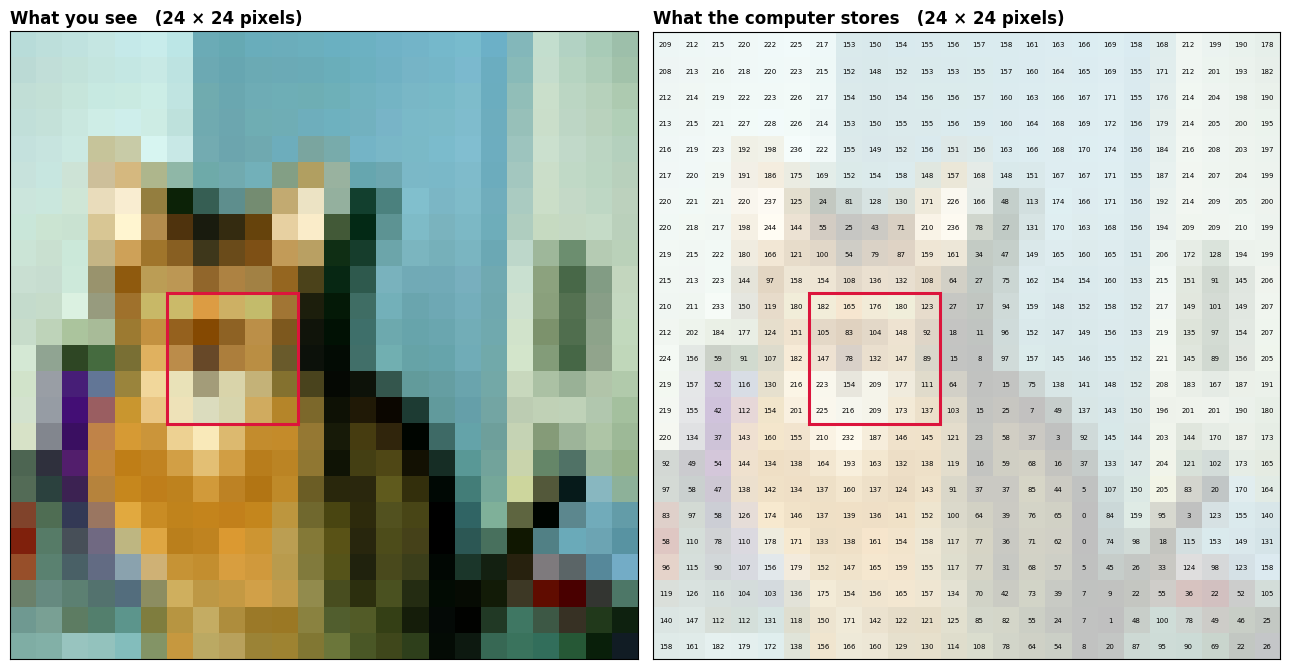

In [2]:
N, ZY, ZX, ZS = 24, 10, 6, 5                                    # grid, then the zoom window
full = ImageOps.fit(Image.open(DATA / "oxford-iiit-pet/images/Abyssinian_119.jpg").convert("RGB"),
                    (480, 480), Image.LANCZOS, centering=(0.5, 0.38))
px   = np.asarray(full.resize((N, N), Image.LANCZOS))
lum  = px @ [0.299, 0.587, 0.114]                               # perceived brightness

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 6.9))
left.imshow(px, interpolation="nearest")
right.imshow(px, interpolation="nearest", alpha=0.25)
for i in range(N):
    for j in range(N):
        right.text(j, i, f"{lum[i, j]:.0f}", ha="center", va="center", fontsize=5)
for ax, title in ((left, "What you see"), (right, "What the computer stores")):
    ax.add_patch(plt.Rectangle((ZX - .5, ZY - .5), ZS, ZS, fill=False, ec="crimson", lw=2.2))
    ax.set_title(f"{title}   ({N} × {N} pixels)", loc="left", weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

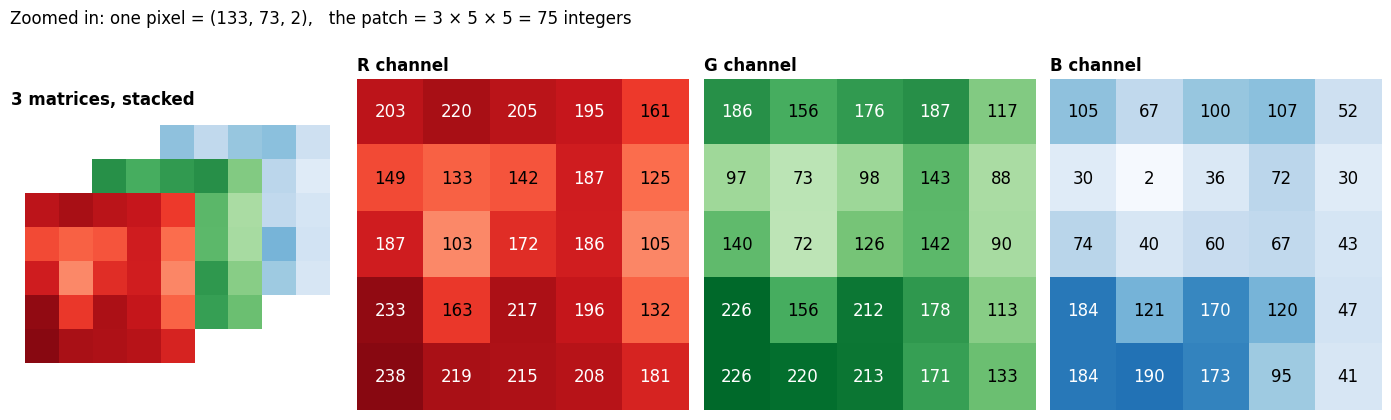

In [3]:
patch = px[ZY:ZY + ZS, ZX:ZX + ZS]                              # the red box, (5, 5, 3)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.2))
for k, cmap in ((2, "Blues"), (1, "Greens"), (0, "Reds")):      # back to front
    axes[0].imshow(patch[..., k], cmap=cmap, vmin=0, vmax=255, zorder=3 - k,
                   extent=(2 * k, 2 * k + ZS, ZS - k, -k))
axes[0].set_xlim(-.4, ZS + 4.4); axes[0].set_ylim(ZS + .4, -2.4)
axes[0].set_title("3 matrices, stacked", loc="left", weight="bold")

for ax, k, cmap in zip(axes[1:], range(3), ("Reds", "Greens", "Blues")):
    ax.imshow(patch[..., k], cmap=cmap, vmin=0, vmax=255)
    for i in range(ZS):
        for j in range(ZS):
            ax.text(j, i, patch[i, j, k], ha="center", va="center", fontsize=12,
                    color="w" if patch[i, j, k] > 165 else "black")
    ax.set_title(f"{'RGB'[k]} channel", loc="left", weight="bold")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)
fig.suptitle(f"Zoomed in: one pixel = {tuple(patch[1, 1])},   the patch = 3 × {ZS} × {ZS} "
             f"= {3 * ZS * ZS} integers", x=.01, y=1.02, ha="left", fontsize=12)
plt.tight_layout(); plt.show()

## 2. Images as tensors

- A **tensor** is an *n*-dimensional array; **shape** gives the size of each axis
- scalar `()` · vector `(2,)` · matrix `(176, 176)` · image `(3, 176, 176)` · batch `(32, 3, 176, 176)`
- PyTorch puts channels first, and adds a batch axis in front
- `ToTensor` maps 0–255 to 0.0–1.0; `Normalize` recentres to roughly mean 0, std 1

In [4]:
normalise = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # ImageNet stats
x = transforms.ToTensor()(full)

print(f"shape {tuple(x.shape)}  dtype {x.dtype}  range {x.min():.2f}..{x.max():.2f}")
print(f"batched {tuple(x[None].shape)}")
print(f"pixel ({ZY + 1}, {ZX + 1}) = {(transforms.ToTensor()(full.resize((N, N))) [:, ZY + 1, ZX + 1] * 255).int().tolist()}")
print(f"after Normalize: mean {normalise(x).mean():+.3f}  std {normalise(x).std():.3f}")

shape (3, 480, 480)  dtype torch.float32  range 0.00..1.00
batched (1, 3, 480, 480)
pixel (11, 7) = [142, 80, 8]
after Normalize: mean +0.356  std 1.207


## 3. One convolutional layer

- One small **kernel** (3 × 3 × 3 = 27 weights + 1 bias) slides over the whole image
- At each position: multiply, sum, add bias → one number
- The result is a **feature map**; then ReLU clamps negatives, pooling halves the size
- Same weights everywhere, so a shifted cat gives a shifted feature map

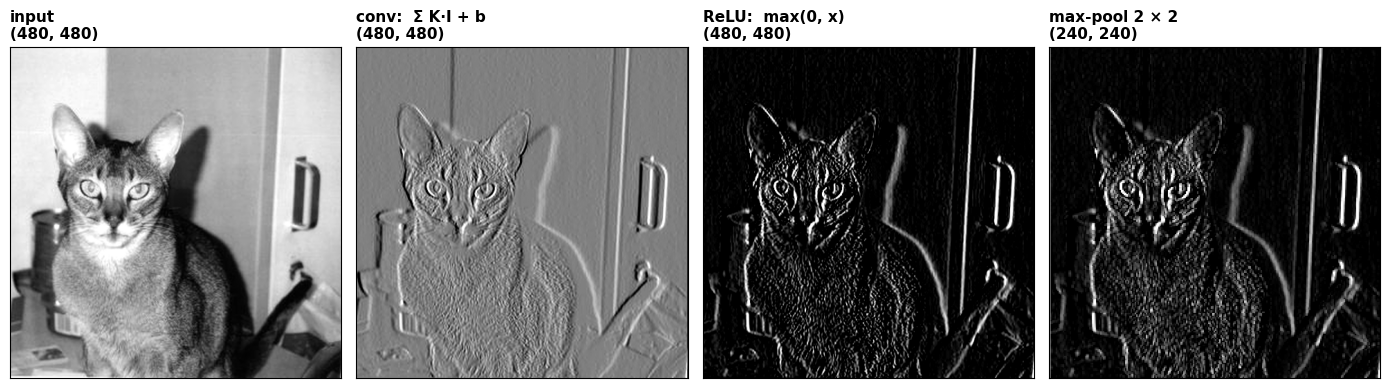

In [5]:
grey   = torch.from_numpy(np.asarray(full.convert("L"), np.float32) / 255)[None, None]
kernel = torch.tensor([[-1., 0, 1], [-2, 0, 2], [-1, 0, 1]])[None, None]         # vertical edges

conv = F.conv2d(grey, kernel, bias=torch.tensor([0.]), padding=1)
relu = F.relu(conv)
pool = F.max_pool2d(relu, 2)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, t, title in zip(axes, (grey, conv, relu, pool),
                        ("input", "conv:  Σ K·I + b", "ReLU:  max(0, x)", "max-pool 2 × 2")):
    a = t[0, 0].numpy()
    lim = np.percentile(np.abs(a), 99)                  # ignore a few extreme pixels
    ax.imshow(a, cmap="gray", vmin=-lim if a.min() < 0 else 0, vmax=lim)
    ax.set_title(f"{title}\n{tuple(t.shape[-2:])}", loc="left", fontsize=11, weight="bold")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 4. The convolution equation

$$
S(i,\,j) \;=\; b \;+\; \sum_{c}\;\sum_{u}\;\sum_{v}\; K(c,\,u,\,v)\;\cdot\;I\bigl(c,\; i\,s+u-p,\; j\,s+v-p\bigr)
$$

| Symbol | Meaning |
|:--|:--|
| $I$ | input, shape $(C_{\text{in}}, H, W)$ — the image, or the previous layer's output |
| $K$ | kernel, shape $(C_{\text{in}}, k_h, k_w)$ — the weights being learned |
| $b$ | bias, one scalar per output channel |
| $S(i,j)$ | one cell of the output feature map |
| $c$ | input channel; $u, v$ position inside the kernel; $i, j$ position in the output |
| $s$ | stride — how far the window jumps |
| $p$ | padding — zeros added around the edge |

$$H_{\text{out}} = \left\lfloor \frac{H + 2p - k_h}{s} \right\rfloor + 1$$

- $k = 3,\; p = 1,\; s = 1$ leaves the size unchanged; $s = 2$ halves it
- Libraries skip the kernel flip of true convolution — the kernel is learned, so it does not matter

In [6]:
def convolve(I, K, b=0.0, stride=1, padding=0):
    """The equation above, as loops.  I: (C, H, W)   K: (C, kh, kw)."""
    C, H, W = I.shape
    _, kh, kw = K.shape
    Ip = np.pad(I, ((0, 0), (padding, padding), (padding, padding)))
    S = np.zeros(((H + 2 * padding - kh) // stride + 1, (W + 2 * padding - kw) // stride + 1))

    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            window = Ip[:, i * stride:i * stride + kh, j * stride:j * stride + kw]
            S[i, j] = b + (K * window).sum()
    return S

rng = np.random.default_rng(SEED)
I, K, b = rng.random((3, 12, 12)), rng.standard_normal((3, 3, 3)), 0.5
theirs = F.conv2d(torch.from_numpy(I)[None], torch.from_numpy(K)[None],
                  torch.tensor([b], dtype=torch.float64), padding=1)[0, 0].numpy()

print(f"my loops {convolve(I, K, b, padding=1).shape}  ==  F.conv2d {theirs.shape}"
      f"   max difference {np.abs(convolve(I, K, b, padding=1) - theirs).max():.1e}")

my loops (12, 12)  ==  F.conv2d (12, 12)   max difference 3.6e-15


## 5. Labels: 0 is cat, 1 is dog

- The label is just an index — the model never sees the words
- It emits **two numbers**; the larger one wins
- `trainval` is split into train and validation; the `test` split is kept back for section 9
- Two thirds of the photos are dogs, so *always guess dog* scores 68% — that is the bar

train 1600   val 600   test 3669 (held out)
trainval balance:  cats 1188   dogs 2492


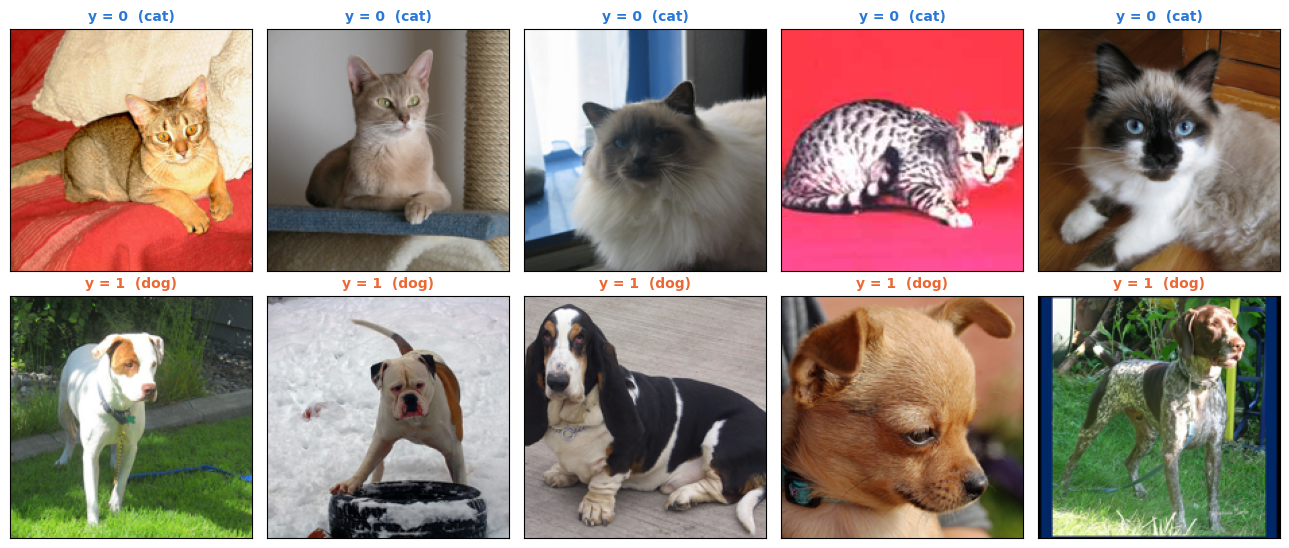

In [7]:
IMG_SIZE = 176
train_tf = transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalise])
eval_tf  = transforms.Compose([transforms.Resize(202), transforms.CenterCrop(IMG_SIZE),
                               transforms.ToTensor(), normalise])

def pet_data(split, tf):
    return OxfordIIITPet(DATA, split=split, transform=tf, target_transform=to_binary)

N_TRAIN, N_VAL = 1600, 600
order    = torch.randperm(len(pets), generator=torch.Generator().manual_seed(SEED)).tolist()
train_ds = Subset(pet_data("trainval", train_tf), order[:N_TRAIN])
val_ds   = Subset(pet_data("trainval", eval_tf), order[N_TRAIN:N_TRAIN + N_VAL])
test_ds  = pet_data("test", eval_tf)

labels = np.array([to_binary(y) for y in pets._labels])
print(f"train {N_TRAIN}   val {N_VAL}   test {len(test_ds)} (held out)")
print(f"trainval balance:  cats {(labels == 0).sum()}   dogs {(labels == 1).sum()}")

fig, axes = plt.subplots(2, 5, figsize=(13, 5.6))
paths = np.array(pets._images)
for row, y in enumerate((0, 1)):
    for ax, p in zip(axes[row], paths[labels == y][[3, 40, 120, 260, 430]]):
        ax.imshow(ImageOps.fit(Image.open(p).convert("RGB"), (180, 180)))
        ax.set_title(f"y = {y}  ({CLASSES[y]})", fontsize=10,
                     color="#2a78d6" if y == 0 else "#eb6834", weight="bold")
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. The model

- ResNet-18, already trained on 1.28M ImageNet photos — it knows edges, fur, eyes
- Swap the 1000-way head for a 2-way one
- Freeze everything except `layer4` and `fc`, so the generic early filters stay put

In [8]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
for name, p in model.named_parameters():
    p.requires_grad_(name.startswith(("layer4", "fc")))
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"{trainable:,} trainable of {total:,} parameters ({trainable / total:.0%})")

8,394,754 trainable of 11,177,538 parameters (75%)


## 7. Backpropagation, epochs, hyperparameters

**Backpropagation**

- **Forward** — image → two numbers → loss, a single "how wrong was that"
- **Backward** — the chain rule runs the path in reverse and gives every weight a gradient
- A gradient says: *nudge me up and the loss moves by this much*
- Each weight steps a little the other way: $w \leftarrow w - \eta\,\partial L/\partial w$
- In PyTorch that whole sweep is `loss.backward()`

**Epoch**

- One **epoch** = one full pass over the training set
- Served in mini-batches of 32; each batch is one forward, one backward, one update
- Here: 1600 / 32 = 50 updates per epoch

**Hyperparameters**

| Knob | Controls | If it is wrong |
|:--|:--|:--|
| learning rate $\eta$ | step size | too high: loss blows up · too low: nothing moves |
| batch size | images per update | small: noisy · large: more memory |
| epochs | passes over the data | too few: underfit · too many: overfit |
| weight decay | pulls weights toward zero | too high: underfits |
| frozen depth | how much backbone adapts | unfreeze all on small data and it memorises |
| augmentation | synthetic variety | none: memorises the training photos |

- Training loss falling only proves memorisation — **validation** accuracy is the honest signal

## 8. The training loop

In [9]:
LR, BATCH_SIZE, EPOCHS, WEIGHT_DECAY = 3e-4, 32, 4, 1e-4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)

criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                              lr=LR, weight_decay=WEIGHT_DECAY)

def run_epoch(loader, train):
    model.train(train)
    loss_sum = correct = seen = 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)                      # forward
            loss   = criterion(logits, labels)          # how wrong
            if train:
                optimiser.zero_grad()
                loss.backward()                         # backward
                optimiser.step()                        # nudge the weights
            loss_sum += loss.item() * len(labels)
            correct  += (logits.argmax(1) == labels).sum().item()
            seen     += len(labels)
    return loss_sum / seen, correct / seen

history = []
print(f"{'epoch':<12}{'train loss':>11}{'train acc':>11}{'val loss':>11}{'val acc':>10}{'time':>9}")
for epoch in ["0 (before)"] + list(range(1, EPOCHS + 1)):
    t0 = time.time()
    tr = run_epoch(train_loader, train=epoch != "0 (before)")
    va = run_epoch(val_loader, train=False)
    history.append(tr + va)
    print(f"{epoch:<12}{tr[0]:>11.4f}{tr[1]:>10.1%}{va[0]:>11.4f}{va[1]:>9.1%}{time.time() - t0:>8.1f}s")

epoch        train loss  train acc   val loss   val acc     time
0 (before)       0.6978     55.6%     0.6918    56.7%    10.2s
1                0.1269     94.4%     0.0607    97.3%    11.6s
2                0.0702     97.8%     0.0595    97.7%    15.2s
3                0.0242     99.2%     0.0326    98.7%    14.8s
4                0.0293     98.9%     0.0587    98.0%    14.6s


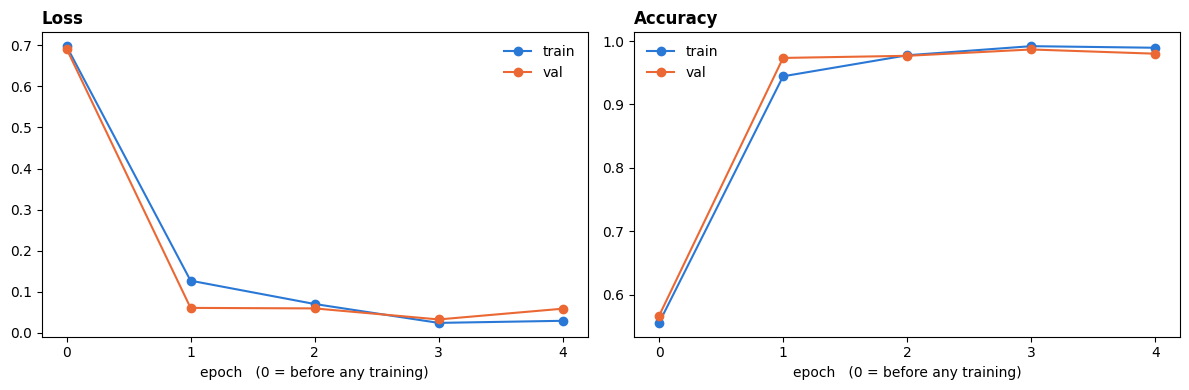

In [10]:
history = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cols, title in ((axes[0], (0, 2), "Loss"), (axes[1], (1, 3), "Accuracy")):
    for col, split, colour in zip(cols, ("train", "val"), ("#2a78d6", "#eb6834")):
        ax.plot(history[:, col], color=colour, marker="o", label=split)
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel("epoch   (0 = before any training)")
    ax.set_xticks(range(len(history)))
    ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 9. Predicting on an unseen cat

- From the `test` split — no weight was ever updated on this photo
- Two **logits** out; **softmax** turns them into probabilities that sum to 1
- `argmax` picks the winner, the probability is the confidence

true label 0 (cat)

  cat  logit  +4.1236    probability 0.999910
  dog  logit  -5.1960    probability 0.000090

prediction 0 (cat)   confidence 99.9910%   correct


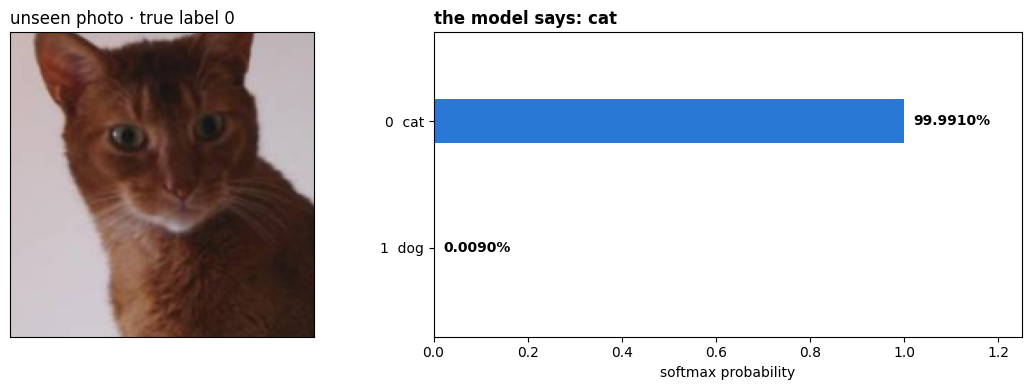

In [11]:
UNSEEN = int(np.flatnonzero(np.array([to_binary(y) for y in test_ds._labels]) == 0)[7])
image, label = test_ds[UNSEEN]

model.eval()
with torch.no_grad():
    logits = model(image[None].to(DEVICE))[0].cpu()
probs = logits.softmax(0)

print(f"true label {label} ({CLASSES[label]})\n")
for k, name in enumerate(CLASSES):
    print(f"  {name:<4} logit {logits[k]:>+8.4f}    probability {probs[k]:.6f}")
pred = int(probs.argmax())
print(f"\nprediction {pred} ({CLASSES[pred]})   confidence {probs[pred]:.4%}   "
      f"{'correct' if pred == label else 'WRONG'}")

mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.4]})
ax_img.imshow((image * std + mean).clamp(0, 1).permute(1, 2, 0))
ax_img.set_title(f"unseen photo · true label {label}", loc="left")
ax_img.set_xticks([]); ax_img.set_yticks([])
ax_bar.barh([1, 0], [probs[0].item(), probs[1].item()], height=.35, color=["#2a78d6", "#eb6834"])
ax_bar.set_yticks([1, 0], [f"0  {CLASSES[0]}", f"1  {CLASSES[1]}"])
for y, k in ((1, 0), (0, 1)):
    ax_bar.text(probs[k] + .02, y, f"{probs[k]:.4%}", va="center", weight="bold")
ax_bar.set_xlim(0, 1.25); ax_bar.set_ylim(-.7, 1.7); ax_bar.set_xlabel("softmax probability")
ax_bar.set_title(f"the model says: {CLASSES[pred]}", loc="left", weight="bold")
plt.tight_layout(); plt.show()

**One photo proves nothing** — here is the whole held-out split.

In [12]:
subset = Subset(test_ds, range(0, len(test_ds), 4))              # ~900 unseen photos
probs_all, true_all = [], []
with torch.no_grad():
    for images, labels in DataLoader(subset, batch_size=64):
        probs_all.append(model(images.to(DEVICE)).softmax(1).cpu())
        true_all.append(labels)

probs_all, true_all = torch.cat(probs_all), torch.cat(true_all)
pred_all = probs_all.argmax(1)

print(f"{len(true_all):,} held-out photos   accuracy {(pred_all == true_all).float().mean():.2%}")
for k, name in enumerate(CLASSES):
    mask = true_all == k
    print(f"  was {name:<4} {mask.sum():>4} photos   recall {(pred_all[mask] == k).float().mean():.1%}")

918 held-out photos   accuracy 98.91%
  was cat   296 photos   recall 98.0%
  was dog   622 photos   recall 99.4%
